<a href="https://colab.research.google.com/github/hafnailmy-bip/pertemuan1/blob/main/PCD_Tugas_Citra_Digital.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Foto Tugas Citra Digital.jpeg to Foto Tugas Citra Digital (2).jpeg
=== PARAMETER CITRA ===
Resolusi        : 1200 x 1600
Bit depth       : uint8
Aspect ratio    : 0.75
Format file     : jpeg
Ukuran file     : 206.78 KB

=== HASIL INSPEKSI ===
Jumlah cacat      : 4
Total area cacat  : 182748 pixel
Keputusan produk  : NG (Reject Product)

=== PERFORMA SISTEM ===
Waktu proses      : 0.0393 detik
Estimasi memori   : 1500.0 KB


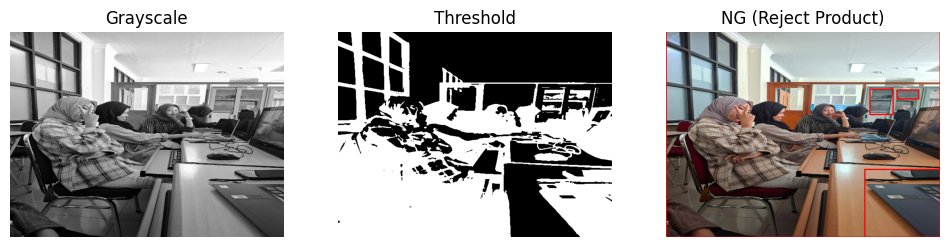

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import os, time, sys

# =====================================================
# AKUISISI CITRA (SIMULASI KAMERA INDUSTRI)
# =====================================================
uploaded = files.upload()
filename = list(uploaded.keys())[0]

start_time = time.time()

# Baca gambar
image = cv2.imread(filename)

# Parameter teknis citra
height, width, channel = image.shape
resolution = f"{width} x {height}"
bit_depth = image.dtype
aspect_ratio = width/height
file_size = os.path.getsize(filename)/1024  # KB
file_format = filename.split('.')[-1]

print("=== PARAMETER CITRA ===")
print("Resolusi        :", resolution)
print("Bit depth       :", bit_depth)
print("Aspect ratio    :", round(aspect_ratio,2))
print("Format file     :", file_format)
print("Ukuran file     :", round(file_size,2),"KB")

# Resize standar kamera QC
image = cv2.resize(image, (640,480))

# =====================================================
# PREPROCESSING
# =====================================================
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray,(5,5),0)

# Enhancement (meningkatkan kontras)
gray = cv2.equalizeHist(gray)

# Threshold
_, thresh = cv2.threshold(blur,120,255,cv2.THRESH_BINARY_INV)

# =====================================================
# ANALISIS (DETEKSI CACAT)
# =====================================================
contours,_ = cv2.findContours(thresh,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

defect_count = 0
total_area = 0

for cnt in contours:
    area = cv2.contourArea(cnt)

    if area > 500:  # filter noise
        defect_count += 1
        total_area += area

        x,y,w,h = cv2.boundingRect(cnt)
        cv2.rectangle(image,(x,y),(x+w,y+h),(0,0,255),2)

# Keputusan industri
status = "NG (Reject Product)" if defect_count>0 else "OK (Accepted Product)"

# =====================================================
# OUTPUT SISTEM
# =====================================================
process_time = time.time() - start_time
memory_usage = (image.nbytes + gray.nbytes + thresh.nbytes)/1024

print("\n=== HASIL INSPEKSI ===")
print("Jumlah cacat      :", defect_count)
print("Total area cacat  :", int(total_area),"pixel")
print("Keputusan produk  :", status)

print("\n=== PERFORMA SISTEM ===")
print("Waktu proses      :", round(process_time,4),"detik")
print("Estimasi memori   :", round(memory_usage,2),"KB")

# =====================================================
# VISUALISASI
# =====================================================
plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.title("Grayscale")
plt.imshow(gray,cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Threshold")
plt.imshow(thresh,cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title(status)
plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.show()